# BEE 4750 Lab 2: Monte Carlo

**Name**: Moho Goswami

**ID**: mg2297

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [2]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `c:\Users\mohog\lab-2-mohogos`


In [3]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [4]:
Random.seed!(1)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [5]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 1
 3
 5
 4
 6
 2
 5
 5
 5
 2
 ⋮
 3
 6
 5
 5
 6
 3
 6
 6
 6

And then we can plot a histogram of these rolls:

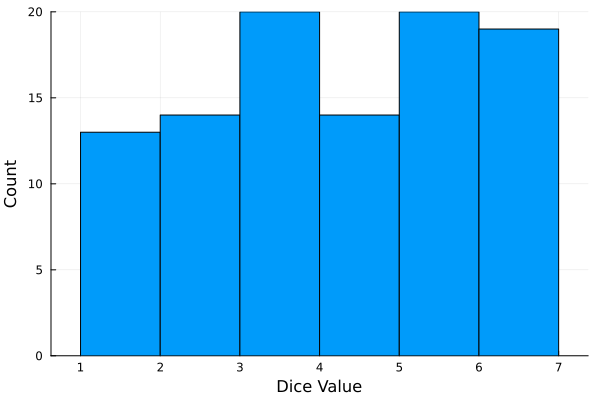

In [6]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

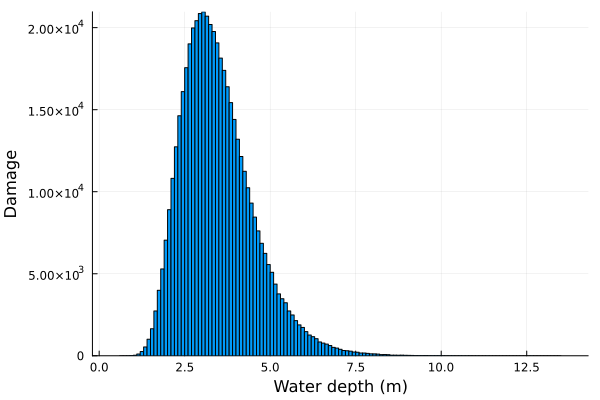

In [36]:
# Defining function and variables
# L = 200000
# k = 0.8
# h0 = 3
d(h) = 200000 / (1 + exp(-0.8 * (h - 3)))

# Apply LogNormal probability distribution
ln_distribution = LogNormal(1.2, 0.3)
ln_damage_sims = rand(ln_distribution,500000)
damage_samples = d.(ln_damage_sims)

# Plot histogram of LogNormal distribution
histogram(ln_damage_sims, legend=:false, bins=200)
ylabel!("Damage")
xlabel!("Water depth (m)")

In [31]:
# Output Monte Carlo estimates
mean_ln_distribution = mean(damage_samples)
q99_ln_distribution = quantile(damage_samples, 0.99)

println("LogNormal Distribution:")
println("  Expected damage: \$$(round(mean_ln_distribution; digits=2))")
println("  99% quantile of damage: \$$(round(q99_ln_distribution; digits=2))")

LogNormal Distribution:
  Expected damage: $115148.6
  99% quantile of damage: $189813.09


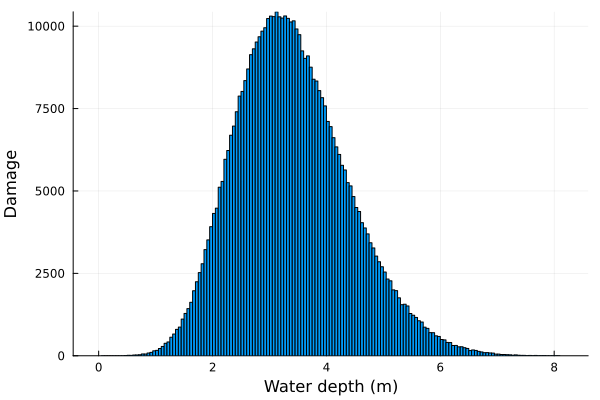

In [32]:
# Given
d(h) = 200000 / (1 + exp(-0.8 * (h - 3)))

# Apply GeneralizedExtremeValue probability distribution
using Distributions: GeneralizedExtremeValue
depth_distribution = GeneralizedExtremeValue(3, 0.9, -0.15)
depth_damage_sims = rand(depth_distribution, 500000)
damage_samples = d.(depth_damage_sims)

# Plot histogram of LogNormal distribution
histogram(depth_damage_sims, legend=:false, bins=200)
ylabel!("Damage")
xlabel!("Water depth (m)")

In [33]:
# Output Monte Carlo estimates
mean_depth_distribution = mean(damage_samples)
q99_depth_distribution = quantile(damage_samples, 0.99)

println("LogNormal Distribution:")
println("  Expected damage: \$$(round(mean_depth_distribution; digits=2))")
println("  99% quantile of damage: \$$(round(q99_depth_distribution; digits=2))")

LogNormal Distribution:
  Expected damage: $113533.55
  99% quantile of damage: $183286.65



1) What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
* For the LogNormal distribution, the expected value estimate is $115,126.72, while the 99% quantile is $189,944.27
* For the GEV distribution, the expected value estimate is $113,501.13, while the 99% quantile is $183,335.49.
2)   How did you decide on your sample size?
* I had initially used a sample size of 100, but the data was sparsely populated - several gaps existed between bars and a clear shape of the graph was not discernable. I also wanted to ensure that the graph values didn't appear to be getting cut off at the top; through trial and error I kept increasing the sample size until I settled on n = 500,000.
3)   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
* The estimates for the expected value and 99% quantile were both nearly identical for the two distributions. Given that the same data is being used, this suggests that both probability distributions are highly precise when compared with each other. It is worth noting that the curve of the LogNormal distribution appears to be skewed right, whereas the curve of the GEV distribution is more uniform. The slightly higher values of the expected value estimate and 99% quantile for the LogNormal curve are likely attributable to the nature of the graph's shape.
4)  How might you decide (based on getting additional information, if
    needed) which distribution is “better”?
* A "better" distribution can be defined here as one that more closely matches real-world data. As such, useful additional information would include data on actual floods, including what the depth of water was above ground and the amount of economic loss that occurred. It would also be helpful to see if one of these distributions can be applied more universally by comparing flood data for different geographic regions and climates; this may also reveal that both distributions are highly accurate but for different locations. Lastly, this run assumed specific values for L, k, and h0, thus another metric by which to measure which distribution is superior could be how reliable they both remain when these values are changed - does one of these distributions sharply decrease in accuracy when a threshold on these constants is exceeded, for example?

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

* https://docs.julialang.org/en/v1/manual/mathematical-operations/